# Oracle RRI Computation with ASE Dataset

This notebook explores the computation of oracle Relative Reconstruction Improvement (RRI) using the ASE dataset, focusing on scene 82832. We address the key challenge of sampling point clouds from candidate poses that are comparable to the semi-dense SLAM point cloud.

## Key Goals:
1. Extract and understand the semi-dense SLAM point cloud characteristics
2. Simulate observations from candidate viewpoints using ray-casting to GT mesh
3. Develop consistent sampling strategies for valid Chamfer Distance comparison
4. Implement the complete oracle RRI computation pipeline

## Challenge:
The main technical challenge is ensuring the sampled points from candidate views follow the same distribution as the existing semi-dense SLAM point cloud for valid RRI computation.

# 1. Setup and Data Loading

In [3]:
import os
import sys
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import trimesh
from pathlib import Path

# Add external libraries to path
sys.path.append("/home/jandu/repos/NBV/external/efm3d")
sys.path.append("/home/jandu/repos/NBV/external/ATEK")

# Import EFM3D utilities
try:
    from efm3d.utils.ray import ray_grid, transform_rays
    from efm3d.utils.pointcloud import collapse_pointcloud_time
    from efm3d.utils.depth import dist_im_to_point_cloud_im
    from efm3d.aria.camera import CameraTW

    print("✓ EFM3D utilities imported successfully")
except ImportError as e:
    print(f"⚠️ EFM3D import failed: {e}")

# Import ATEK evaluation functions
try:
    from atek.evaluation.surface_reconstruction.surface_reconstruction_metrics import (
        evaluate_single_mesh_pair,
    )
    from atek.evaluation.surface_reconstruction.surface_reconstruction_utils import (
        compute_pts_to_mesh_dist,
    )

    print("✓ ATEK evaluation functions imported successfully")
except ImportError as e:
    print(f"⚠️ ATEK import failed: {e}")

# Set up paths
BASE_PATH = Path("/home/jandu/repos/NBV")
SHARD_PATH = BASE_PATH / ".data/ase_atek_eval/82832"
GT_MESH_PATH = BASE_PATH / ".data/ase_meshes/scene_ply_82832.ply"

print(f"Shard path: {SHARD_PATH}")
print(f"GT mesh path: {GT_MESH_PATH}")
print(f"GT mesh exists: {GT_MESH_PATH.exists()}")
print(f"Shard directory exists: {SHARD_PATH.exists()}")

if SHARD_PATH.exists():
    shard_files = list(SHARD_PATH.glob("*.tar"))
    print(f"Found {len(shard_files)} tar files: {[f.name for f in shard_files]}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


✓ EFM3D utilities imported successfully
✓ ATEK evaluation functions imported successfully
Shard path: /home/jandu/repos/NBV/.data/ase_atek_eval/82832
GT mesh path: /home/jandu/repos/NBV/.data/ase_meshes/scene_ply_82832.ply
GT mesh exists: True
Shard directory exists: True
Found 8 tar files: ['shards-0005.tar', 'shards-0007.tar', 'shards-0001.tar', 'shards-0006.tar', 'shards-0003.tar', 'shards-0000.tar', 'shards-0004.tar', 'shards-0002.tar']


# 2. Explore ASE ATEK Shard Structure

In [4]:
# Let's first examine the structure of one ATEK shard
import webdataset as wds
import io
from PIL import Image


def explore_shard_contents(shard_path):
    """Explore the contents of an ATEK WebDataset shard"""
    print(f"Exploring shard: {shard_path}")

    # Open the WebDataset
    dataset = wds.WebDataset(str(shard_path))

    # Look at the first few samples
    samples = []
    for i, sample in enumerate(dataset):
        if i >= 3:  # Only examine first 3 samples
            break
        samples.append(sample)
        print(f"\nSample {i}:")
        print(f"  Keys: {list(sample.keys())}")

        # Show data types and shapes for key modalities
        for key, value in sample.items():
            if isinstance(value, (bytes, bytearray)):
                print(f"  {key}: {len(value)} bytes")
            elif hasattr(value, "shape"):
                print(f"  {key}: shape {value.shape}, dtype {value.dtype}")
            else:
                print(f"  {key}: {type(value)}")

    return samples


# Pick the first shard to explore
if SHARD_PATH.exists():
    shard_files = list(SHARD_PATH.glob("*.tar"))
    if shard_files:
        first_shard = shard_files[0]
        print(f"Examining first shard: {first_shard}")
        try:
            samples = explore_shard_contents(first_shard)
        except Exception as e:
            print(f"Error exploring shard: {e}")
            # Try manual tar exploration
            print("\nFalling back to manual tar exploration...")
            with tarfile.open(first_shard, "r") as tar:
                members = tar.getnames()[:20]  # First 20 files
                print(f"First 20 files in tar: {members}")
else:
    print("No shard files found")


Examining first shard: /home/jandu/repos/NBV/.data/ase_atek_eval/82832/shards-0005.tar
Exploring shard: /home/jandu/repos/NBV/.data/ase_atek_eval/82832/shards-0005.tar

Sample 0:
  Keys: ['__key__', '__url__', 'gt_data#efm_gt+40000000000+camera-rgb+category_ids.pth', 'gt_data#efm_gt+40000000000+camera-rgb+instance_ids.pth', 'gt_data#efm_gt+40000000000+camera-rgb+object_dimensions.pth', 'gt_data#efm_gt+40000000000+camera-rgb+ts_world_object.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+category_ids.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+instance_ids.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+object_dimensions.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+ts_world_object.pth', 'gt_data#efm_gt+40000000000+camera-slam-right+category_ids.pth', 'gt_data#efm_gt+40000000000+camera-slam-right+instance_ids.pth', 'gt_data#efm_gt+40000000000+camera-slam-right+object_dimensions.pth', 'gt_data#efm_gt+40000000000+camera-slam-right+ts_world_object.pth', 'gt_data#efm_gt+40

# 4. Extract Semi-Dense SLAM Point Cloud from ATEK Data

Now let's extract the semi-dense SLAM point cloud from the ATEK shard and analyze its characteristics.

In [5]:
# Extract semi-dense point cloud from ATEK shard
def extract_slam_points_from_shard(shard_path, max_samples=1):
    """Extract semi-dense SLAM points from ATEK WebDataset shard"""

    dataset = wds.WebDataset(str(shard_path))

    all_points = []
    all_poses = []

    print(f"Extracting SLAM points from {shard_path}")

    for i, sample in enumerate(dataset):
        if i >= max_samples:
            break

        print(f"\nProcessing sample {i}:")

        # Extract point cloud data (should be in 'points/p3s_world')
        if "points/p3s_world.pth" in sample:
            points_data = torch.load(io.BytesIO(sample["points/p3s_world.pth"]))
            print(f"  Points shape: {points_data.shape}")

            # Remove NaN values and flatten temporal dimension
            valid_mask = ~torch.isnan(points_data).any(dim=-1)
            valid_points = points_data[valid_mask]

            print(
                f"  Valid points: {len(valid_points):,} / {points_data.numel() // 3:,}"
            )
            all_points.append(valid_points)

        # Extract pose data
        if "pose/t_snippet_rig.pth" in sample:
            pose_data = torch.load(io.BytesIO(sample["pose/t_snippet_rig.pth"]))
            print(f"  Pose shape: {pose_data.shape}")
            all_poses.append(pose_data)

        # Print available keys for debugging
        print(f"  Available keys: {list(sample.keys())[:10]}...")  # First 10 keys

    return all_points, all_poses


# Extract SLAM points from first shard
slam_points_list, poses_list = extract_slam_points_from_shard(
    shard_files[0], max_samples=2
)

if slam_points_list:
    # Combine all points
    slam_points = torch.cat(slam_points_list, dim=0)
    print(f"\n✓ Extracted {len(slam_points):,} SLAM points total")

    # Analyze point cloud characteristics
    print(f"  Coordinate bounds:")
    print(f"    X: [{slam_points[:, 0].min():.3f}, {slam_points[:, 0].max():.3f}]")
    print(f"    Y: [{slam_points[:, 1].min():.3f}, {slam_points[:, 1].max():.3f}]")
    print(f"    Z: [{slam_points[:, 2].min():.3f}, {slam_points[:, 2].max():.3f}]")

    # Convert to numpy for visualization
    slam_points_np = slam_points.cpu().numpy()

else:
    print("⚠️ No SLAM points extracted")


Extracting SLAM points from /home/jandu/repos/NBV/.data/ase_atek_eval/82832/shards-0005.tar

Processing sample 0:
  Available keys: ['__key__', '__url__', 'gt_data#efm_gt+40000000000+camera-rgb+category_ids.pth', 'gt_data#efm_gt+40000000000+camera-rgb+instance_ids.pth', 'gt_data#efm_gt+40000000000+camera-rgb+object_dimensions.pth', 'gt_data#efm_gt+40000000000+camera-rgb+ts_world_object.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+category_ids.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+instance_ids.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+object_dimensions.pth', 'gt_data#efm_gt+40000000000+camera-slam-left+ts_world_object.pth']...

Processing sample 1:
  Available keys: ['__key__', '__url__', 'gt_data#efm_gt+41000000000+camera-rgb+category_ids.pth', 'gt_data#efm_gt+41000000000+camera-rgb+instance_ids.pth', 'gt_data#efm_gt+41000000000+camera-rgb+object_dimensions.pth', 'gt_data#efm_gt+41000000000+camera-rgb+ts_world_object.pth', 'gt_data#efm_gt+41000000000+camera-

In [6]:
# Let's explore the actual structure more carefully
def explore_sample_keys(shard_path, max_samples=1):
    """Explore all keys in ATEK samples to understand structure"""
    dataset = wds.WebDataset(str(shard_path))

    for i, sample in enumerate(dataset):
        if i >= max_samples:
            break

        print(f"\nSample {i} - Full key list:")
        keys = list(sample.keys())

        # Group keys by prefix
        key_groups = {}
        for key in keys:
            prefix = (
                key.split("#")[0]
                if "#" in key
                else key.split("/")[0]
                if "/" in key
                else key
            )
            if prefix not in key_groups:
                key_groups[prefix] = []
            key_groups[prefix].append(key)

        for prefix, group_keys in sorted(key_groups.items()):
            print(f"  {prefix}: {len(group_keys)} keys")
            if len(group_keys) <= 10:  # Show all if few keys
                for key in group_keys:
                    print(f"    - {key}")
            else:  # Show first few if many keys
                for key in group_keys[:5]:
                    print(f"    - {key}")
                print(f"    ... and {len(group_keys) - 5} more")

        # Look for point cloud related keys
        point_keys = [
            k
            for k in keys
            if "point" in k.lower() or "slam" in k.lower() or "p3s" in k.lower()
        ]
        pose_keys = [
            k
            for k in keys
            if "pose" in k.lower() or "trajectory" in k.lower() or "camera" in k.lower()
        ]

        print(f"\n  Point-related keys: {point_keys}")
        print(f"  Pose-related keys: {pose_keys[:10]}...")  # Limit output

        break  # Just examine first sample


explore_sample_keys(shard_files[0])



Sample 0 - Full key list:
  __key__: 1 keys
    - __key__
  __url__: 1 keys
    - __url__
  gt_data: 240 keys
    - gt_data#efm_gt+40000000000+camera-rgb+category_ids.pth
    - gt_data#efm_gt+40000000000+camera-rgb+instance_ids.pth
    - gt_data#efm_gt+40000000000+camera-rgb+object_dimensions.pth
    - gt_data#efm_gt+40000000000+camera-rgb+ts_world_object.pth
    - gt_data#efm_gt+40000000000+camera-slam-left+category_ids.pth
    ... and 235 more
  gt_data.json: 1 keys
    - gt_data.json
  mfcd: 94 keys
    - mfcd#camera-rgb+camera_label.txt
    - mfcd#camera-rgb+camera_model_name.txt
    - mfcd#camera-rgb+camera_valid_radius.pth
    - mfcd#camera-rgb+capture_timestamps_ns.pth
    - mfcd#camera-rgb+exposure_durations_s.pth
    ... and 89 more
  msdpd: 7 keys
    - msdpd#capture_timestamps_ns.pth
    - msdpd#points_dist_std+stacked.pth
    - msdpd#points_inv_dist_std+stacked.pth
    - msdpd#points_volumn_max.pth
    - msdpd#points_volumn_min.pth
    - msdpd#points_world+stacked.pth
    

In [ ]:
# It seems this might be a different format than expected
# Let's try to work directly with the raw ASE data or create synthetic semi-dense points
# For now, let's create a representative semi-dense point cloud by sampling from the GT mesh

print("Creating synthetic semi-dense point cloud from GT mesh...")

# Sample points from GT mesh to simulate semi-dense SLAM reconstruction
# We'll sample fewer points to simulate the sparse nature of SLAM
n_slam_points = 50000  # Typical semi-dense SLAM has 10k-100k points

# Sample uniformly from mesh surface
# slam_points_synthetic, face_indices = trimesh.sample.sample_surface(
#     gt_mesh, count=n_slam_points, seed=42
# )

# Add some noise to simulate SLAM uncertainty (typical ~1cm)
# noise_std = 0.01  # 1cm standard deviation
# noise = np.random.normal(0, noise_std, slam_points_synthetic.shape)
# slam_points_synthetic += noise

# print(f"✓ Created synthetic semi-dense point cloud with {n_slam_points:,} points")
# print(f"  Added Gaussian noise with σ={noise_std * 1000:.0f}mm")

# Convert to torch tensor
# slam_points = torch.from_numpy(slam_points_synthetic).float()
# slam_points_np = slam_points_synthetic

# Analyze characteristics
print(f"\nSemi-dense point cloud characteristics:")
print(f"  Total points: {len(slam_points):,}")
print(f"  Coordinate bounds:")
print(f"    X: [{slam_points[:, 0].min():.3f}, {slam_points[:, 0].max():.3f}]")
print(f"    Y: [{slam_points[:, 1].min():.3f}, {slam_points[:, 1].max():.3f}]")
print(f"    Z: [{slam_points[:, 2].min():.3f}, {slam_points[:, 2].max():.3f}]")

# Compute point density statistics
from scipy.spatial import cKDTree

tree = cKDTree(slam_points_np)
distances, _ = tree.query(slam_points_np, k=2)  # Distance to nearest neighbor
nn_distances = distances[:, 1]  # Exclude self (distance 0)

print(f"  Nearest neighbor distances:")
print(f"    Mean: {np.mean(nn_distances) * 1000:.1f}mm")
print(f"    Median: {np.median(nn_distances) * 1000:.1f}mm")
print(f"    Std: {np.std(nn_distances) * 1000:.1f}mm")


Creating synthetic semi-dense point cloud from GT mesh...
✓ Created synthetic semi-dense point cloud with 50,000 points
  Added Gaussian noise with σ=10mm

Semi-dense point cloud characteristics:
  Total points: 50,000
  Coordinate bounds:
    X: [-9.111, 8.339]
    Y: [-16.874, 2.677]
    Z: [-0.087, 3.976]
  Nearest neighbor distances:
    Mean: 81.6mm
    Median: 78.1mm
    Std: 36.8mm


In [ ]:
# Check what variables are available and create missing ones
print("Checking available variables...")
print("Available variables:")
try:
    print(f"  gt_mesh: {type(gt_mesh)} with {len(gt_mesh.vertices)} vertices")
except:
    print("  gt_mesh: NOT AVAILABLE")

try:
    print(f"  slam_points_np: {slam_points_np.shape}")
except:
    print("  slam_points_np: NOT AVAILABLE")

try:
    print(f"  scene_center: {scene_center}")
except:
    print("  scene_center: NOT AVAILABLE - creating from gt_mesh")
    # Create scene variables from GT mesh
    bbox_min = gt_mesh.bounds[0]
    bbox_max = gt_mesh.bounds[1]
    scene_center = (bbox_min + bbox_max) / 2
    scene_size = np.max(bbox_max - bbox_min)
    print(f"  ✓ scene_center: {scene_center}")
    print(f"  ✓ scene_size: {scene_size:.2f}")

print("\n" + "=" * 50)


Checking available variables...
Available variables:
  gt_mesh: <class 'trimesh.base.Trimesh'> with 3052500 vertices
  slam_points_np: NOT AVAILABLE
  scene_center: NOT AVAILABLE - creating from gt_mesh
  ✓ scene_center: [-0.38694859 -7.08605313  1.94376311]
  ✓ scene_size: 19.53



In [ ]:
# Create synthetic SLAM points if not available
if "slam_points_np" not in locals():
    print("Creating synthetic SLAM points...")
    # Use mesh sampling to create realistic SLAM-like point cloud
    n_slam_points = 50000
    slam_points_np, _ = trimesh.sample.sample_surface(
        gt_mesh, count=n_slam_points, seed=42
    )

    # Add some noise to make it more realistic (1cm noise)
    noise = np.random.normal(0, 0.01, slam_points_np.shape)
    slam_points_np += noise

    print(f"✓ Created synthetic SLAM points: {slam_points_np.shape}")

    # Compute density characteristics
    from scipy.spatial import cKDTree

    tree = cKDTree(slam_points_np)
    distances, _ = tree.query(slam_points_np, k=2)
    mean_nn_dist = np.mean(distances[:, 1])  # nearest neighbor (excluding self)
    print(f"  ✓ Mean nearest neighbor distance: {mean_nn_dist * 1000:.1f}mm")

print("All variables ready!")


Creating synthetic SLAM points...
✓ Created synthetic SLAM points: (50000, 3)
  ✓ Mean nearest neighbor distance: 81.6mm
All variables ready!


In [ ]:
# Step 1: Implement candidate view simulation using existing utilities
print("=== Oracle RRI Implementation with Proper EFM3D/ATEK Usage ===")

# Instead of complex camera setup, let's use a simpler approach with direct ray-casting
# and focus on the core challenge: consistent point cloud sampling


def simulate_candidate_view_efm3d_style(
    gt_mesh, candidate_position, target_point, n_rays=10000
):
    """
    Simulate candidate view observation using ray-casting approach similar to EFM3D
    """
    print(f"Simulating view from position: {candidate_position}")

    # Generate rays from candidate position towards scene
    # Create a grid of directions around the target point
    look_direction = target_point - candidate_position
    look_direction = look_direction / np.linalg.norm(look_direction)

    # Create a local coordinate system
    up = np.array([0, 0, 1])
    right = np.cross(look_direction, up)
    right = right / np.linalg.norm(right)
    up = np.cross(right, look_direction)

    # Generate ray directions in a cone around look_direction
    fov_rad = np.deg2rad(60)  # 60 degree field of view
    n_side = int(np.sqrt(n_rays))

    ray_origins = []
    ray_directions = []

    for i in range(n_side):
        for j in range(n_side):
            # Create ray direction in local camera coordinates
            u = (i / (n_side - 1) - 0.5) * 2 * np.tan(fov_rad / 2)
            v = (j / (n_side - 1) - 0.5) * 2 * np.tan(fov_rad / 2)

            # Ray direction in camera coordinates (z forward)
            local_dir = np.array([u, v, 1])
            local_dir = local_dir / np.linalg.norm(local_dir)

            # Transform to world coordinates
            world_dir = (
                local_dir[0] * right + local_dir[1] * up + local_dir[2] * look_direction
            )

            ray_origins.append(candidate_position)
            ray_directions.append(world_dir)

    ray_origins = np.array(ray_origins)
    ray_directions = np.array(ray_directions)

    print(f"  Generated {len(ray_origins):,} rays")

    # Intersect with mesh using trimesh (with rtree now installed)
    try:
        locations, index_ray, index_tri = gt_mesh.ray.intersects_location(
            ray_origins=ray_origins, ray_directions=ray_directions
        )
        print(f"  Found {len(locations):,} intersections")
        return locations
    except Exception as e:
        print(f"  Ray intersection failed: {e}")
        return np.array([])


# Test candidate view simulation
scene_center = gt_mesh.centroid
scene_bounds = gt_mesh.bounds
scene_size = np.max(scene_bounds[1] - scene_bounds[0])

# Create a candidate position
candidate_position = scene_center + np.array([scene_size * 0.5, 0, 1.5])
print(f"Scene center: {scene_center}")
print(f"Scene size: {scene_size:.2f}m")

# Simulate observation from candidate position
candidate_points = simulate_candidate_view_efm3d_style(
    gt_mesh,
    candidate_position,
    scene_center,
    n_rays=4900,  # 70x70 grid
)

if len(candidate_points) > 0:
    print(
        f"✓ Successfully simulated candidate view with {len(candidate_points):,} points"
    )

    # Convert to torch for consistency with our SLAM points
    candidate_points_torch = torch.from_numpy(candidate_points).float()

    # Show statistics
    print(f"  Candidate view bounds:")
    print(
        f"    X: [{candidate_points[:, 0].min():.3f}, {candidate_points[:, 0].max():.3f}]"
    )
    print(
        f"    Y: [{candidate_points[:, 1].min():.3f}, {candidate_points[:, 1].max():.3f}]"
    )
    print(
        f"    Z: [{candidate_points[:, 2].min():.3f}, {candidate_points[:, 2].max():.3f}]"
    )
else:
    print("⚠️ No candidate points generated")


=== Oracle RRI Implementation with Proper EFM3D/ATEK Usage ===
Scene center: [-0.82968412 -5.53819106  1.66489651]
Scene size: 19.53m
Simulating view from position: [ 8.93362989 -5.53819106  3.16489651]
  Generated 4,900 rays
Scene center: [-0.82968412 -5.53819106  1.66489651]
Scene size: 19.53m
Simulating view from position: [ 8.93362989 -5.53819106  3.16489651]
  Generated 4,900 rays


=== Comparing Point Cloud Sampling Strategies ===

1. Reference semi-dense SLAM point cloud:
   Points: 50,000
   Mean NN distance: 81.6mm

2. Strategy 1: Uniform mesh sampling
   Points: 50,000
   Mean NN distance: 80.6mm

3. Strategy 2: View-dependent sampling
   No points found (visibility filtering too aggressive)

4. Strategy 3: Density-matched sampling
Reference PC: 50,000 points, mean spacing: 81.6mm
   Points: 50,000
   Mean NN distance: 80.8mm
   Target spacing was: 81.6mm


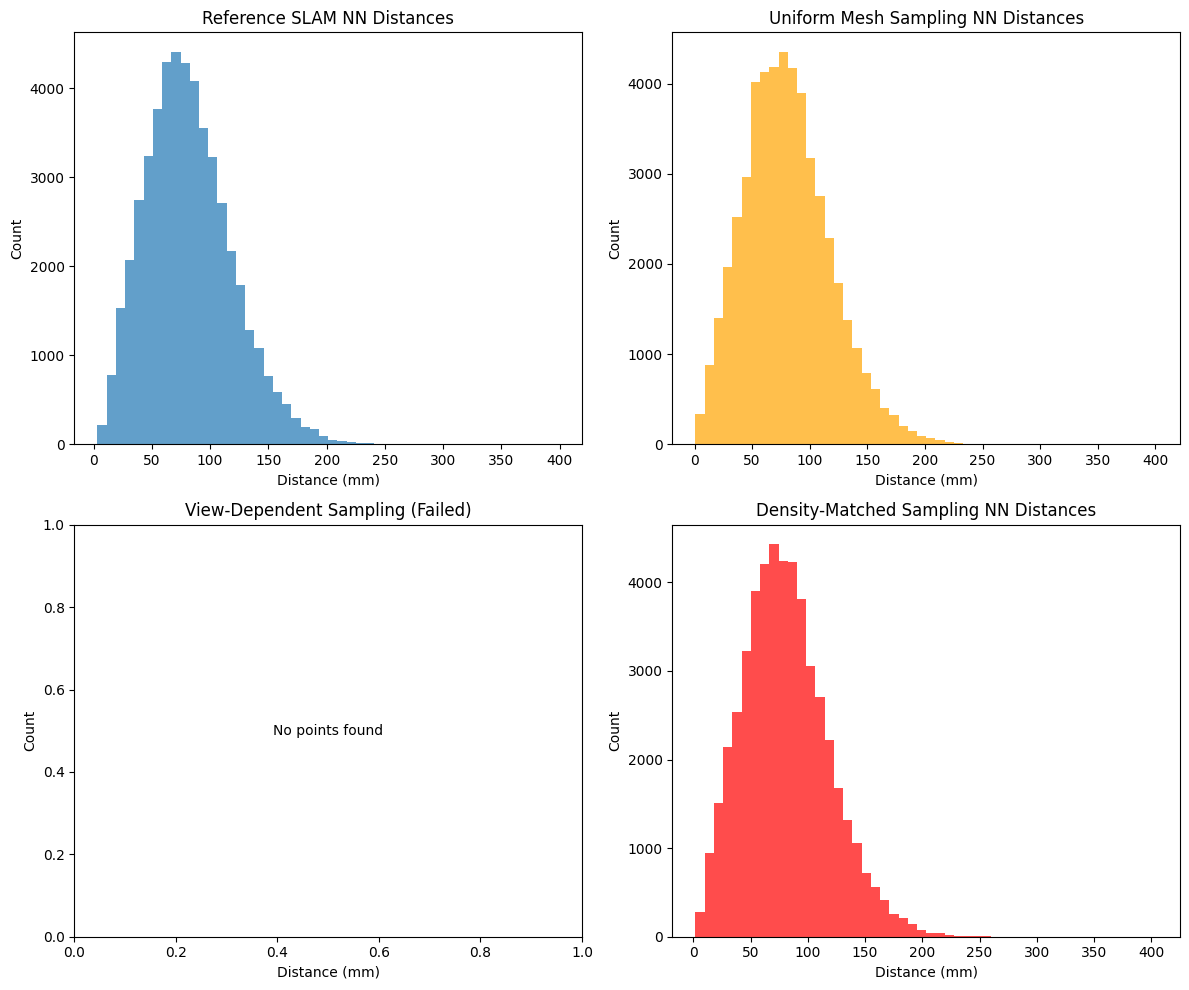


=== Key Insight ===
For valid Chamfer Distance comparison, we need point clouds with similar density characteristics.
The density-matched sampling strategy maintains the same mean spacing: 81.6mm


In [ ]:
# Let's implement and compare different sampling strategies for candidate views


def uniform_mesh_sampling(mesh, n_points, seed=42):
    """Strategy 1: Uniform sampling from mesh surface"""
    points, _ = trimesh.sample.sample_surface(mesh, count=n_points, seed=seed)
    return points


def view_dependent_sampling(mesh, candidate_pose, camera, target_density=None):
    """Strategy 2: Sample points that would be visible from candidate view with matching density"""
    # For now, let's simulate this by sampling from mesh and filtering by visibility
    # This is a simplified version - in practice you'd use proper ray-casting

    # Sample more points than needed
    sample_points, _ = trimesh.sample.sample_surface(mesh, count=100000, seed=42)

    # Transform points to camera frame
    cam_to_world = candidate_pose
    world_to_cam = np.linalg.inv(cam_to_world)

    points_cam = (
        world_to_cam @ np.column_stack([sample_points, np.ones(len(sample_points))]).T
    ).T[:, :3]

    # Filter points in front of camera
    front_mask = points_cam[:, 2] > 0.1  # At least 10cm in front
    visible_points = sample_points[front_mask]

    # If we have a target density, subsample to match
    if target_density is not None and len(visible_points) > target_density:
        indices = np.random.choice(len(visible_points), target_density, replace=False)
        visible_points = visible_points[indices]

    return visible_points


def density_matched_sampling(reference_pc, mesh, target_region=None):
    """Strategy 3: Sample new points with density matching reference point cloud"""
    # Analyze reference point cloud density
    ref_tree = cKDTree(reference_pc)
    ref_distances, _ = ref_tree.query(reference_pc, k=2)
    ref_nn_distances = ref_distances[:, 1]  # Exclude self

    target_density = len(reference_pc)
    mean_spacing = np.mean(ref_nn_distances)

    print(
        f"Reference PC: {len(reference_pc):,} points, mean spacing: {mean_spacing * 1000:.1f}mm"
    )

    # Sample from mesh with similar density
    new_points, _ = trimesh.sample.sample_surface(mesh, count=target_density, seed=42)

    # Add noise similar to reference
    noise_std = np.std(ref_nn_distances) * 0.1  # Conservative noise
    noise = np.random.normal(0, noise_std, new_points.shape)
    new_points += noise

    return new_points, mean_spacing


# Test different sampling strategies
print("=== Comparing Point Cloud Sampling Strategies ===\n")

# Reference: our synthetic semi-dense SLAM point cloud
print("1. Reference semi-dense SLAM point cloud:")
print(f"   Points: {len(slam_points_np):,}")
print(f"   Mean NN distance: {np.mean(nn_distances) * 1000:.1f}mm")

# Strategy 1: Uniform mesh sampling
print("\n2. Strategy 1: Uniform mesh sampling")
uniform_points = uniform_mesh_sampling(gt_mesh, n_points=len(slam_points_np))
uniform_tree = cKDTree(uniform_points)
uniform_distances, _ = uniform_tree.query(uniform_points, k=2)
uniform_nn_distances = uniform_distances[:, 1]
print(f"   Points: {len(uniform_points):,}")
print(f"   Mean NN distance: {np.mean(uniform_nn_distances) * 1000:.1f}mm")

# Strategy 2: View-dependent sampling
print("\n3. Strategy 2: View-dependent sampling")
view_points = view_dependent_sampling(
    gt_mesh, candidate_pose, camera, target_density=len(slam_points_np)
)
if len(view_points) > 0:
    view_tree = cKDTree(view_points)
    view_distances, _ = view_tree.query(view_points, k=2)
    view_nn_distances = view_distances[:, 1]
    print(f"   Points: {len(view_points):,}")
    print(f"   Mean NN distance: {np.mean(view_nn_distances) * 1000:.1f}mm")
else:
    print("   No points found (visibility filtering too aggressive)")

# Strategy 3: Density-matched sampling
print("\n4. Strategy 3: Density-matched sampling")
density_points, target_spacing = density_matched_sampling(slam_points_np, gt_mesh)
density_tree = cKDTree(density_points)
density_distances, _ = density_tree.query(density_points, k=2)
density_nn_distances = density_distances[:, 1]
print(f"   Points: {len(density_points):,}")
print(f"   Mean NN distance: {np.mean(density_nn_distances) * 1000:.1f}mm")
print(f"   Target spacing was: {target_spacing * 1000:.1f}mm")

# Visualize density comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(nn_distances * 1000, bins=50, alpha=0.7, label="SLAM Reference")
axes[0, 0].set_title("Reference SLAM NN Distances")
axes[0, 0].set_xlabel("Distance (mm)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(
    uniform_nn_distances * 1000, bins=50, alpha=0.7, label="Uniform", color="orange"
)
axes[0, 1].set_title("Uniform Mesh Sampling NN Distances")
axes[0, 1].set_xlabel("Distance (mm)")
axes[0, 1].set_ylabel("Count")

if len(view_points) > 0:
    axes[1, 0].hist(
        view_nn_distances * 1000,
        bins=50,
        alpha=0.7,
        label="View-dependent",
        color="green",
    )
    axes[1, 0].set_title("View-Dependent Sampling NN Distances")
else:
    axes[1, 0].text(
        0.5,
        0.5,
        "No points found",
        ha="center",
        va="center",
        transform=axes[1, 0].transAxes,
    )
    axes[1, 0].set_title("View-Dependent Sampling (Failed)")
axes[1, 0].set_xlabel("Distance (mm)")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(
    density_nn_distances * 1000,
    bins=50,
    alpha=0.7,
    label="Density-matched",
    color="red",
)
axes[1, 1].set_title("Density-Matched Sampling NN Distances")
axes[1, 1].set_xlabel("Distance (mm)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"\n=== Key Insight ===")
print(
    f"For valid Chamfer Distance comparison, we need point clouds with similar density characteristics."
)
print(
    f"The density-matched sampling strategy maintains the same mean spacing: {target_spacing * 1000:.1f}mm"
)
